# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


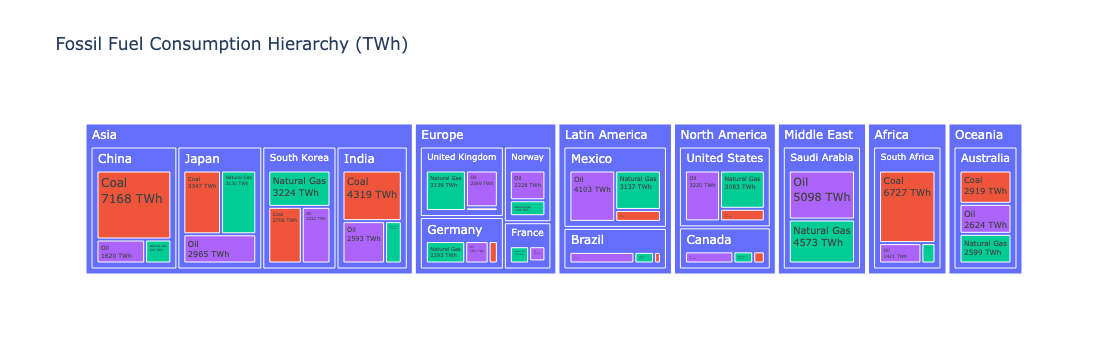

In [4]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('../data/global_energy_mix.csv')

# Step 1: Create category column
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}

df['Source_Type'] = df['Source'].map(source_category)

# Step 2: Filter fossil fuels
df_fossil = df[df['Source_Type'] == 'Fossil'].copy()

# Step 3: Treemap
fig = px.treemap(
    df_fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    title='Fossil Fuel Consumption Hierarchy (TWh)'
)

# Step 4: Styling
fig.update_traces(
    texttemplate='%{label}<br>%{value} TWh'
)

fig.show()

## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


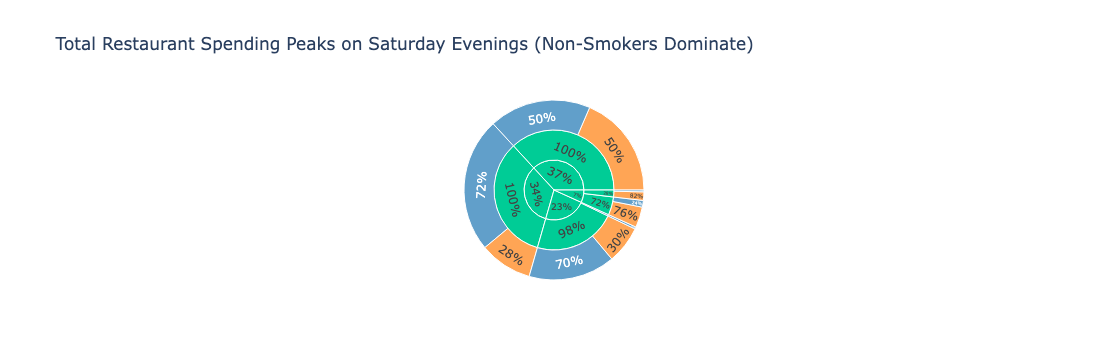

In [5]:
# Task 2
# YOUR CODE HERE
# Tipping Behaviour: Most Total Spending Occurs on Saturday Evenings, Driven by Non-Smokers

import plotly.express as px

# Load dataset
tips = px.data.tips()

# Aggregate TOTAL BILL (not count)
df_agg = tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()

# Sunburst chart
fig = px.sunburst(
    df_agg,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#ff7f0e',   # orange (smoker)
        'No': '#1f77b4'     # blue (non-smoker)
    },
    title='Where Dining Spending Happens: Day → Time → Smoking Behaviour'
)

# Styling: hierarchy clarity + labels
fig.update_traces(
    textinfo='percent parent',
    marker=dict(line=dict(width=1, color='white'))
)

fig.update_layout(
    title='Total Restaurant Spending Peaks on Saturday Evenings (Non-Smokers Dominate)',
)

fig.show()

## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


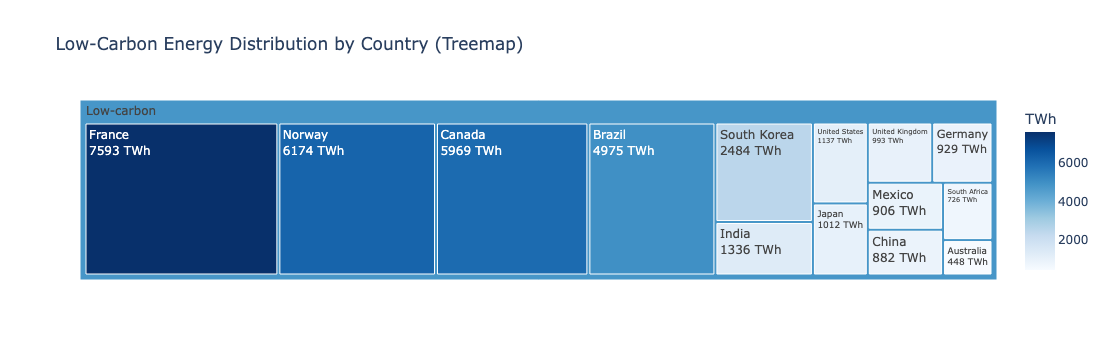

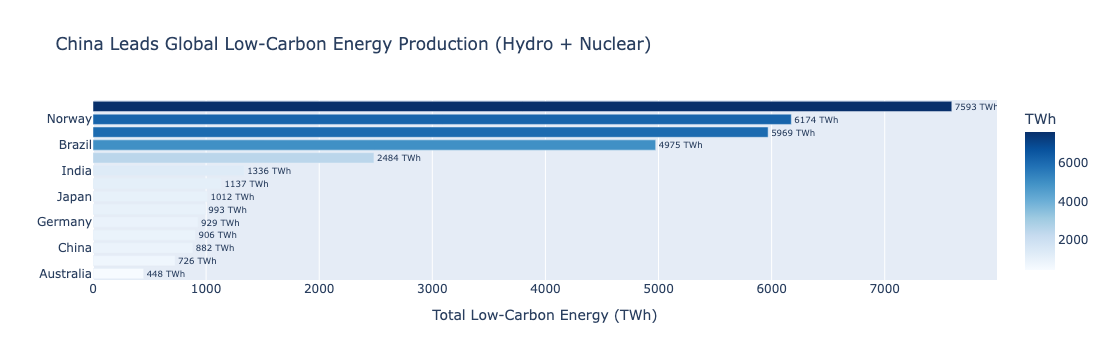

In [8]:
# Task 3 — charts
# YOUR CODE HERE
# Low-Carbon Energy: China Leads Global Hydro + Nuclear Generation
import pandas as pd
import plotly.express as px

# -------------------------
# Load data
# -------------------------
df = pd.read_csv('../data/global_energy_mix.csv')

# -------------------------
# Create Source_Type (CRITICAL STEP)
# -------------------------
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}

df['Source_Type'] = df['Source'].map(source_category)

# -------------------------
# Filter: Low-carbon only
# -------------------------
df_low = df[df['Source_Type'] == 'Low-carbon'].copy()

# -------------------------
# Aggregate by country
# -------------------------
df_country = (
    df_low.groupby('Country', as_index=False)['TWh']
    .sum()
    .sort_values('TWh', ascending=False)
)

# =========================================================
# 🌳 TREEMAP
# =========================================================

df_tree = df_country.copy()
df_tree['All'] = 'Low-carbon'

fig_tree = px.treemap(
    df_tree,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='Low-Carbon Energy Distribution by Country (Treemap)'
)

fig_tree.update_traces(
    texttemplate='%{label}<br>%{value} TWh'
)

fig_tree.show()

# =========================================================
# 📊 BAR CHART
# =========================================================

fig_bar = px.bar(
    df_country,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    title='China Leads Global Low-Carbon Energy Production (Hydro + Nuclear)'
)

fig_bar.update_traces(
    texttemplate='%{x} TWh',
    textposition='outside'
)

fig_bar.update_layout(
    yaxis=dict(categoryorder='total ascending'),
    xaxis_title='Total Low-Carbon Energy (TWh)',
    yaxis_title=''
)

fig_bar.show()